In [76]:
import sys, os

sys.path.append(os.path.abspath(".."))

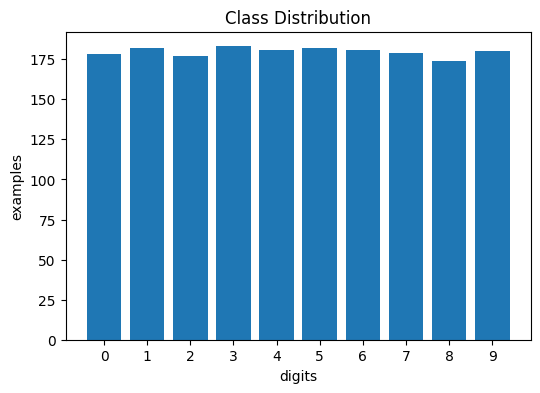

In [77]:
# get the mnist dataset

from sklearn.datasets import load_digits
import numpy as np
import matplotlib.pyplot as plt


digits = load_digits()

# perform some eda
imgs, labels = digits.images, digits.target
counts = np.bincount(labels)

plt.figure(figsize=(6,4))
plt.bar(np.arange(len(counts)).astype(str), counts)
plt.xlabel("digits")
plt.ylabel("examples")
plt.title("Class Distribution")
plt.show()



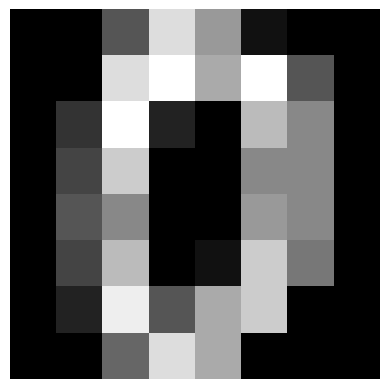

In [78]:
plt.imshow(imgs[0], cmap='gray')
plt.axis('off');

In [79]:
print(imgs.shape)

(1797, 8, 8)


In [80]:
# preprocessing
images = imgs / 16
images = imgs - imgs.mean()

In [81]:
# implement a simple lenet
from models.LeNet import LeNet
import torch
import torch.nn as nn
import torch.nn.functional as F

model = LeNet()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

# make sure they're torch tensors
input = torch.tensor(images, dtype=torch.float32).unsqueeze(1)  # (B, 1, H, W)
input = F.pad(input, (12, 12, 12, 12))                         # pad images to match paper
labels = torch.tensor(labels, dtype=torch.long)

for epoch in range(501):
    
    optimizer.zero_grad()   # fresh reset gradients
    logits = model(input)    
    loss = criterion(logits, labels)   # calculate loss
    
    loss.backward()                    # calculate fresh gradients
    optimizer.step()                   # step applies the lr and new gradients to the weigths and biases
    
    preds = torch.argmax(logits, dim=1)
    acc = (preds == labels).float().mean().item()
    
    if epoch % 50 == 0:
        print(f"step: {epoch} loss {loss.item():.4f}, accuracy {acc*100:.2f}%")

step: 0 loss 2.3032, accuracy 9.91%
step: 50 loss 2.2742, accuracy 22.31%
step: 100 loss 2.1439, accuracy 44.02%
step: 150 loss 1.0557, accuracy 68.06%
step: 200 loss 0.8405, accuracy 70.28%
step: 250 loss 0.4387, accuracy 86.03%
step: 300 loss 0.3606, accuracy 88.37%
step: 350 loss 0.2936, accuracy 90.15%
step: 400 loss 0.2266, accuracy 92.10%
step: 450 loss 0.1929, accuracy 93.16%
step: 500 loss 0.1742, accuracy 94.05%


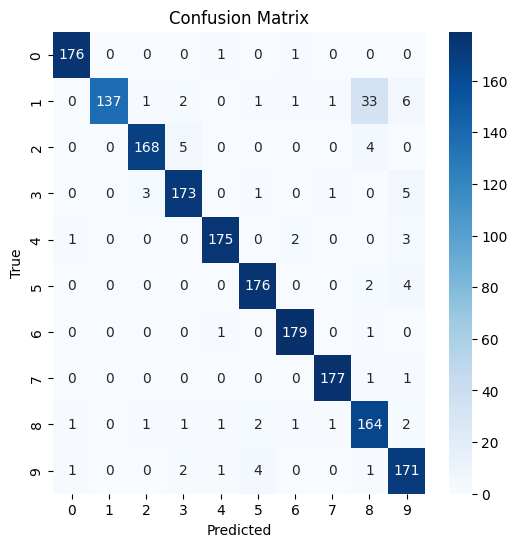

In [82]:
# playing with trained classifier
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model.eval()
with torch.no_grad():
    logits = model(input)
    preds = torch.argmax(logits, dim=1)

cm = confusion_matrix(labels.cpu(), preds.cpu())

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


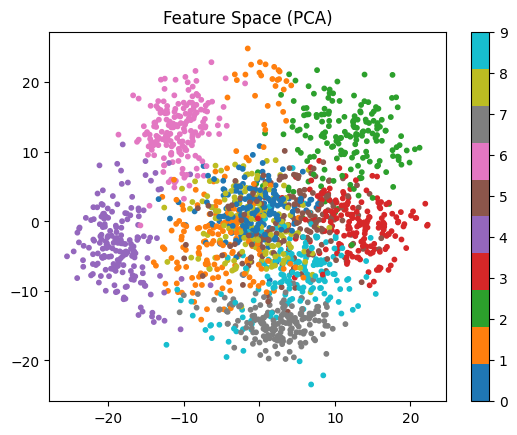

In [83]:
def extract_features(model, x):
    x = F.relu(model.conv1(x))
    x = F.avg_pool2d(x, 2)
    x = F.relu(model.conv2(x))
    x = F.avg_pool2d(x, 2)
    x = torch.flatten(x, 1)
    x = F.relu(model.fc1(x))
    return x

model.eval()
with torch.no_grad():
    feats = extract_features(model, input)   # imgs MUST be torch.Tensor

# convert to numpy ONLY here
feats_np = feats.cpu().numpy()
labels_np = labels.cpu().numpy()

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X2 = pca.fit_transform(feats_np)

plt.scatter(X2[:,0], X2[:,1], c=labels_np, cmap="tab10", s=10)
plt.colorbar()
plt.title("Feature Space (PCA)")
plt.show()


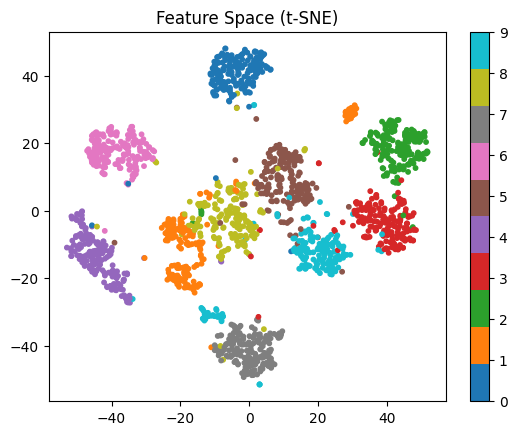

In [84]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=0,
)
X2 = tsne.fit_transform(feats_np)

plt.scatter(X2[:,0], X2[:,1], c=labels_np, cmap="tab10", s=10)
plt.colorbar()
plt.title("Feature Space (t-SNE)")
plt.show()
